# Phase 13 — Deux regards sur le même relevé

## Objectifs

- Faire tourner deux têtes d'attention en parallèle sur le même relevé, chacune avec ses propres
  vecteurs de question, d'étiquette et de contenu, et recoller leurs sorties en une seule.
- Démontrer, matrices à l'appui, qu'elles ne regardent pas la même chose — avec une mesure de
  désaccord justifiée, comparée à un cas de contrôle où deux têtes partiraient identiques.


## 1. Imports

In [1]:
from pathlib import Path
import csv
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn


## 2. Configuration et reprise du relevé des phases 10-11

In [2]:
SEED = 42
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")
DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
PHASE13_DIR = OUTPUT_DIR / "phase_13_attention_multi_tetes"
PHASE13_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = DATA_DIR / "releves_klaxo3.csv"

COLUMNS = [
    "datetime", "city", "state", "country", "shape",
    "duration_seconds", "duration_hours_min", "comments",
    "date_posted", "latitude", "longitude",
]

D_MODEL = 32
NOMBRE_TETES = 2
D_TETE = D_MODEL // NOMBRE_TETES  # 16 : chaque tete travaille dans un sous-espace plus petit
RELEVE_CHOISI_INDEX = 100

lignes_valides = []
with open(DATA_PATH, "r", encoding="utf-8", errors="replace", newline="") as f:
    reader = csv.reader(f)
    for row in reader:
        if len(row) == len(COLUMNS):
            lignes_valides.append(row)
df = pd.DataFrame(lignes_valides, columns=COLUMNS)
df["comments_clean"] = df["comments"].fillna("").astype(str).str.strip()

def tokenizer(texte):
    return re.findall(r"[a-z0-9]+", str(texte).lower())

texte_choisi = df.loc[RELEVE_CHOISI_INDEX, "comments_clean"]
tokens = tokenizer(texte_choisi)
longueur = len(tokens)

vocabulaire = {"<UNK>": 0}
for token in tokens:
    if token not in vocabulaire:
        vocabulaire[token] = len(vocabulaire)
ids = torch.tensor([vocabulaire[t] for t in tokens], dtype=torch.long)

print(f"Relevé (index {RELEVE_CHOISI_INDEX}) : {texte_choisi!r}")
print(f"Jetons ({longueur}) : {tokens}")


Relevé (index 100) : 'Oval shaped with lights all around it in a haze with several smaller lights flying all around it.'
Jetons (18) : ['oval', 'shaped', 'with', 'lights', 'all', 'around', 'it', 'in', 'a', 'haze', 'with', 'several', 'smaller', 'lights', 'flying', 'all', 'around', 'it']


## 3. Une tête, comme fonction réutilisable

Exactement le mécanisme des phases 10-11, mais paramétré pour opérer dans un sous-espace de dimension
`D_TETE` au lieu de `D_MODEL` — c'est ce que veut dire « plusieurs jeux de question, d'étiquette et de
contenu différents » : chaque tête a ses trois couches à elle.

In [3]:
class TeteAttention(nn.Module):
    def __init__(self, d_model, d_tete):
        super().__init__()
        self.couche_question = nn.Linear(d_model, d_tete, bias=False)
        self.couche_etiquette = nn.Linear(d_model, d_tete, bias=False)
        self.couche_contenu = nn.Linear(d_model, d_tete, bias=False)
        self.d_tete = d_tete

    def forward(self, vecteurs):
        questions = self.couche_question(vecteurs)
        etiquettes = self.couche_etiquette(vecteurs)
        contenus = self.couche_contenu(vecteurs)
        scores = questions @ etiquettes.T / (self.d_tete ** 0.5)
        poids = torch.softmax(scores, dim=-1)
        sortie = poids @ contenus
        return sortie, poids


## 4. Deux têtes, initialisées différemment, recollées

In [4]:
embedding = nn.Embedding(len(vocabulaire), D_MODEL)
vecteurs_entree = embedding(ids)

torch.manual_seed(SEED)
tete_1 = TeteAttention(D_MODEL, D_TETE)
torch.manual_seed(SEED + 1)  # graine differente : initialisation differente
tete_2 = TeteAttention(D_MODEL, D_TETE)

couche_recombinaison = nn.Linear(D_MODEL, D_MODEL, bias=False)

sortie_tete_1, poids_tete_1 = tete_1(vecteurs_entree)
sortie_tete_2, poids_tete_2 = tete_2(vecteurs_entree)

sortie_concatenee = torch.cat([sortie_tete_1, sortie_tete_2], dim=-1)  # (longueur, D_MODEL)
sortie_finale = couche_recombinaison(sortie_concatenee)

print(f"Sortie tête 1 : {tuple(sortie_tete_1.shape)} | tête 2 : {tuple(sortie_tete_2.shape)}")
print(f"Sortie concaténée : {tuple(sortie_concatenee.shape)} | sortie finale : {tuple(sortie_finale.shape)}")


Sortie tête 1 : (18, 16) | tête 2 : (18, 16)
Sortie concaténée : (18, 32) | sortie finale : (18, 32)


## 5. Les deux matrices, côte à côte

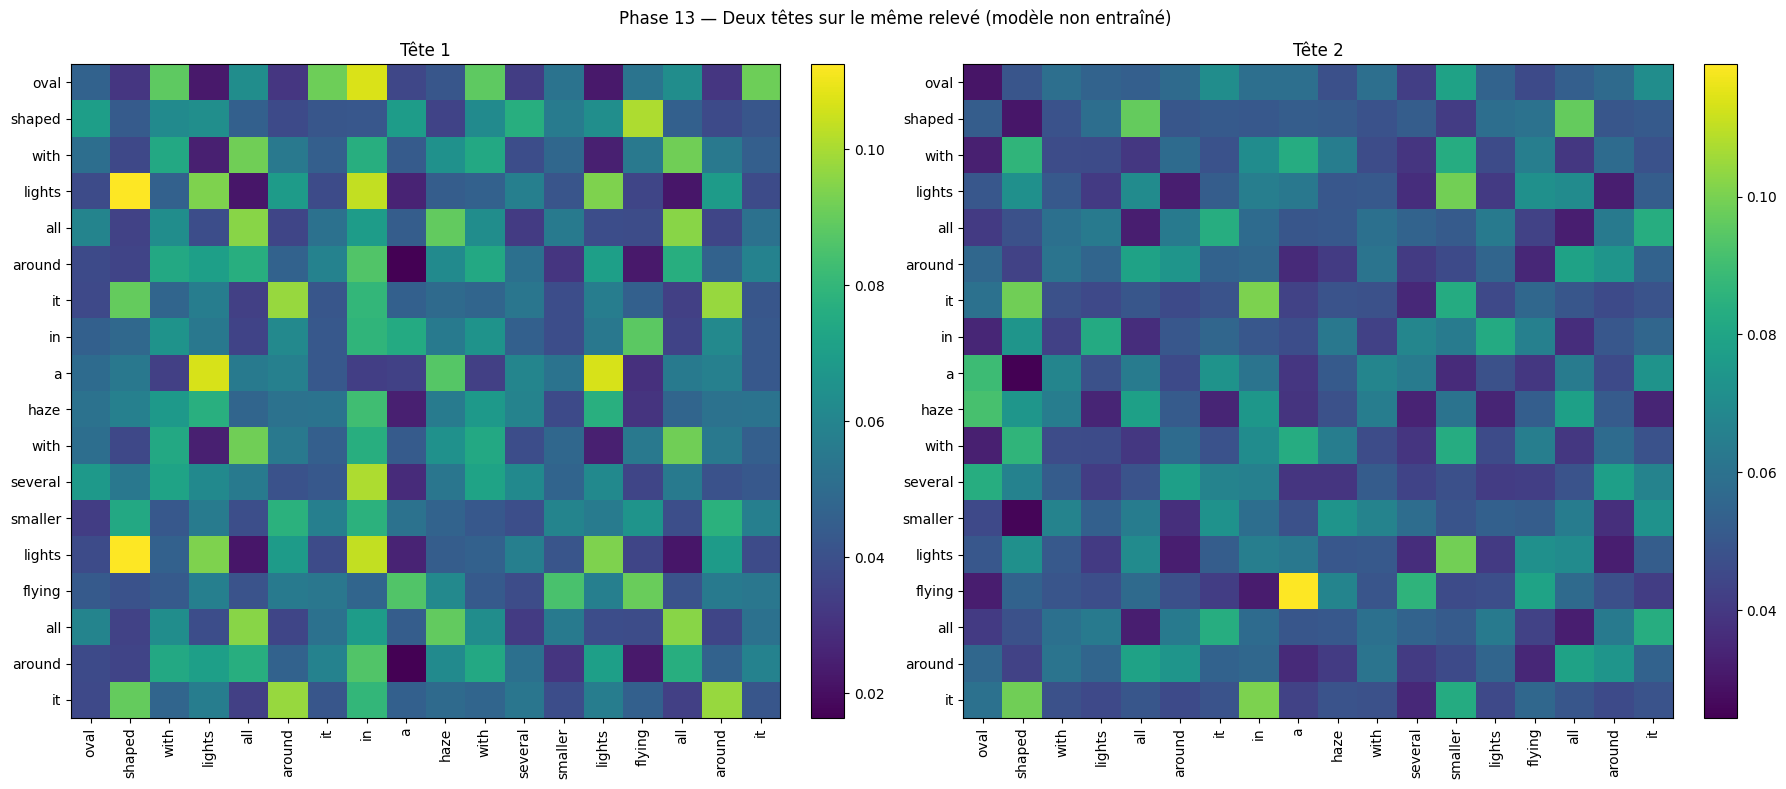

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, matrice, titre in [(axes[0], poids_tete_1, "Tête 1"), (axes[1], poids_tete_2, "Tête 2")]:
    im = ax.imshow(matrice.detach().numpy(), cmap="viridis", aspect="auto")
    ax.set_xticks(range(longueur)); ax.set_xticklabels(tokens, rotation=90)
    ax.set_yticks(range(longueur)); ax.set_yticklabels(tokens)
    ax.set_title(titre)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle("Phase 13 — Deux têtes sur le même relevé (modèle non entraîné)")
plt.tight_layout()
plt.savefig(PHASE13_DIR / "deux_tetes.png", dpi=150)
plt.show()


## 6. Mesure du désaccord, et cas de contrôle

**Mesure choisie** : l'écart absolu moyen, case par case, entre les deux matrices de poids — simple,
symétrique, sur la même échelle [0, 1] que les poids eux-mêmes, donc directement interprétable comme
« en moyenne, de combien les deux têtes diffèrent sur le poids qu'elles accordent à chaque couple de
mots ».

**Cas de contrôle** : deux têtes qui partiraient **identiques** (même graine, mêmes poids). Sans ce
repère, un chiffre de désaccord ne veut rien dire — on ne sait pas si c'est beaucoup ou peu.

In [6]:
def desaccord_moyen(poids_a, poids_b):
    return (poids_a - poids_b).abs().mean().item()

desaccord_reel = desaccord_moyen(poids_tete_1, poids_tete_2)

# Cas de controle : deux tetes strictement identiques (meme graine).
torch.manual_seed(SEED)
tete_controle_a = TeteAttention(D_MODEL, D_TETE)
torch.manual_seed(SEED)
tete_controle_b = TeteAttention(D_MODEL, D_TETE)

_, poids_controle_a = tete_controle_a(vecteurs_entree)
_, poids_controle_b = tete_controle_b(vecteurs_entree)
desaccord_controle = desaccord_moyen(poids_controle_a, poids_controle_b)

print(f"Désaccord moyen, têtes 1 et 2 (initialisations différentes) : {desaccord_reel:.4f}")
print(f"Désaccord moyen, cas de contrôle (deux têtes identiques)    : {desaccord_controle:.10f}")
print(f"Rapport (réel / contrôle) : {'infini (contrôle exactement nul)' if desaccord_controle == 0 else f'{desaccord_reel/desaccord_controle:.1f}'}")


Désaccord moyen, têtes 1 et 2 (initialisations différentes) : 0.0205
Désaccord moyen, cas de contrôle (deux têtes identiques)    : 0.0000000000
Rapport (réel / contrôle) : infini (contrôle exactement nul)


## 7. Ce que ce chiffre ne prouve pas encore

Le cas de contrôle confirme que le désaccord mesuré n'est pas un artefact de la méthode de mesure
(deux têtes identiques donnent un désaccord nul, au bruit numérique près) : l'écart observé entre les
têtes 1 et 2 vient bien d'une différence réelle entre elles. Mais ces deux têtes ne sont pas
entraînées — leur différence vient uniquement de leur **initialisation aléatoire**, pas d'une
répartition du travail apprise. Si elles l'étaient, on pourrait aller plus loin et vérifier, par
exemple, que chaque tête se spécialise sur un type de relation stable d'un relevé à l'autre (l'une sur
les liens sujet-verbe, l'autre sur les reprises pronominales) — une régularité qu'un modèle non
entraîné ne peut pas présenter, par construction.

## 8. Export

In [7]:
resume_phase13 = pd.DataFrame([{
    "index_releve": RELEVE_CHOISI_INDEX,
    "nombre_jetons": longueur,
    "d_model": D_MODEL,
    "nombre_tetes": NOMBRE_TETES,
    "d_tete": D_TETE,
    "desaccord_moyen_reel": desaccord_reel,
    "desaccord_moyen_controle": desaccord_controle,
}])
resume_phase13.to_csv(PHASE13_DIR / "resume_phase13.csv", index=False)
resume_phase13


,index_releve,nombre_jetons,d_model,nombre_tetes,d_tete,desaccord_moyen_reel,desaccord_moyen_controle
0,100,18,32,2,16,0.020483,0.0
